# Sarcasm Detection

## Importing libraries

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [3]:
import tensorflow as tf

## Extracting and preparing the dataset

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle

!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d rmisra/news-headlines-dataset-for-sarcasm-detection --unzip

  0% 0.00/3.30M [00:00<?, ?B/s]
100% 3.30M/3.30M [00:00<00:00, 110MB/s]


In [6]:
df = pd.read_json('Sarcasm_Headlines_Dataset_v2.json',lines=True)
df.head()

,is_sarcastic,headline,article_link
0,1,thirtysomething scientists unveil doomsday clo...,https://www.theonion.com/thirtysomething-scien...
1,0,dem rep. totally nails why congress is falling...,https://www.huffingtonpost.com/entry/donna-edw...
2,0,eat your veggies: 9 deliciously different recipes,https://www.huffingtonpost.com/entry/eat-your-...
3,1,inclement weather prevents liar from getting t...,https://local.theonion.com/inclement-weather-p...
4,1,mother comes pretty close to using word 'strea...,https://www.theonion.com/mother-comes-pretty-c...


The 'article_link' columns is not needed. So we drop it.

The input to the model will be the headline. 

The output is binary, i.e. 1 if text is sarcastic, 0 if not.

In [7]:
df=df.drop(columns=['article_link'])

In [8]:
X_text=df['headline']

In [9]:
Y=df['is_sarcastic'].values

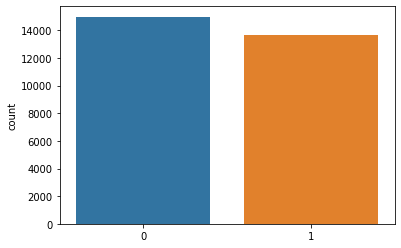

In [10]:
sns.countplot(x=Y)

We can see the data is almost balanced.

## Preparing the text data

First the data is tokenized. Then the tokens are converted into sequences of numbers.

Then the sequences are padded to transform the whole data into a matrix.

In [11]:
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(X_text)
sequences = tokenizer.texts_to_sequences(X_text)

word_index = tokenizer.word_index

In [12]:
len(word_index)

30884

In [13]:
data = tf.keras.preprocessing.sequence.pad_sequences(sequences,padding='post')

The data is split into training and testing with a ratio of 80% and 20% respectively.

In [15]:
X_train, X_test, Y_train, Y_test= train_test_split(data,Y,test_size=0.2,random_state=42)

## Glove Embeddings

We use GloVe embeddings, which is a popular embedding technique based on factorizing a matrix of word co-occurence statistics. 

### Downloading

In [17]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove*.zip

--2021-02-21 14:04:19--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2021-02-21 14:04:19--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2021-02-21 14:04:19--  http://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glove.6

### Computing an index mapping words to known embeddings

We compute an index mapping words to known embeddings

In [18]:
embeddings_index = {}
f = open('glove.6B.100d.txt')
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()


### Creating out embeddings matrix

We use our embedding_index dictionary and our word_index to compute our embedding matrix.

In [19]:
EMBEDDING_DIM=100
embedding_matrix = np.zeros((len(word_index) + 1, EMBEDDING_DIM))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [20]:
embedding_matrix.shape

(30885, 100)

### Creating embedding layer

We load this embedding matrix into an Embedding layer, and freeze the layers to prevent the weights from being updated during training.

In [21]:
embedding_layer = tf.keras.layers.Embedding(len(word_index) + 1,
                            EMBEDDING_DIM,
                            weights=[embedding_matrix],
                            input_length=data.shape[1],
                            trainable=False)

## Model

We create Bidirectional LSTM model. We use the embedding layer which we defined. We add 10% dropout to prevent overfitting. We use ReLU activation for hidden layers, and sigmoid activation function for output layer.

In [27]:
model = tf.keras.Sequential()
model.add(embedding_layer)
model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(10, return_sequences=True)))
model.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(10)))
model.add(tf.keras.layers.Dense(16, activation='relu'))
model.add(tf.keras.layers.Dropout(0.1))
model.add(tf.keras.layers.Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 152, 100)          3088500   
_________________________________________________________________
bidirectional_2 (Bidirection (None, 152, 20)           8880      
_________________________________________________________________
bidirectional_3 (Bidirection (None, 20)                2480      
_________________________________________________________________
dense_2 (Dense)              (None, 16)                336       
_________________________________________________________________
dropout (Dropout)            (None, 16)                0         
_________________________________________________________________
dense_3 (Dense)              (None, 1)                 17        
Total params: 3,100,213
Trainable params: 11,713
Non-trainable params: 3,088,500
_______________________________________

We compile the model using binary cross-entropy as loss function. We use Adam optimizer for training.

In [28]:
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

In [29]:
history=model.fit(X_train, Y_train, epochs=20, validation_split=0.1)

Epoch 1/20
644/644 [==============================] - 22s 26ms/step - loss: 0.5894 - accuracy: 0.6638 - val_loss: 0.4110 - val_accuracy: 0.8214
Epoch 2/20
644/644 [==============================] - 15s 24ms/step - loss: 0.3998 - accuracy: 0.8218 - val_loss: 0.3744 - val_accuracy: 0.8354
Epoch 3/20
644/644 [==============================] - 15s 24ms/step - loss: 0.3547 - accuracy: 0.8442 - val_loss: 0.3493 - val_accuracy: 0.8450
Epoch 4/20
644/644 [==============================] - 15s 24ms/step - loss: 0.3164 - accuracy: 0.8646 - val_loss: 0.3419 - val_accuracy: 0.8463
Epoch 5/20
644/644 [==============================] - 15s 24ms/step - loss: 0.2916 - accuracy: 0.8756 - val_loss: 0.3336 - val_accuracy: 0.8511
Epoch 6/20
644/644 [==============================] - 15s 24ms/step - loss: 0.2797 - accuracy: 0.8824 - val_loss: 0.3498 - val_accuracy: 0.8384
Epoch 7/20
644/644 [==============================] - 15s 24ms/step - loss: 0.2608 - accuracy: 0.8907 - val_loss: 0.3348 - val_accuracy:

We have training accuracy of around 95% and validation accuracy of around 85%.

In [36]:
results=model.evaluate(X_test, Y_test)
print("Testing accuracy: ",results[1])

179/179 [==============================] - 2s 12ms/step - loss: 0.4187 - accuracy: 0.8571
Testing accuracy:  0.8570929169654846


In [ ]:
We have testing accuracy of 85%.